# Predicción de Cancelación de Clientes (Customer Churn)
### Modelos de Machine Learning — Producto 2do. Parcial
**Ingeniería en Desarrollo y Gestión de Software | Enero-Abril 2026**

**Autor:** Gerardo

---

## 1. Planteamiento del problema (enfoque ejecutivo)

**Problema de negocio:** Una empresa de telecomunicaciones pierde clientes de forma
recurrente (*churn*). Cada cliente que cancela representa pérdida de ingresos
recurrentes y un costo de adquisición de un nuevo cliente que, en la industria de
telecomunicaciones, es entre 5 y 7 veces mayor que el costo de retener a uno existente.

**Objetivo analítico:** Construir un modelo de clasificación supervisada que, a partir
de las características del cliente y su servicio contratado, **prediga la probabilidad
de que un cliente cancele su servicio (Churn = Yes/No)**.

**Decisión de negocio que esto habilita:** Con la probabilidad de cancelación por
cliente, el área comercial puede priorizar campañas de retención (descuentos, cambio de
plan, contacto proactivo) hacia el segmento de clientes con **alto riesgo y alto valor**,
en lugar de aplicar acciones de retención genéricas a toda la base de clientes.

---

## 2. Obtención, descripción y comprensión de los datos

**Origen:** *Telco Customer Churn*, dataset público liberado por IBM (IBM Business
Analytics Community / IBM Cognos Analytics samples), ampliamente usado como caso de
referencia para modelos de cancelación de clientes en telecomunicaciones.

**Estructura:** 7,043 registros (clientes) × 21 columnas.

**Variable objetivo:** `Churn` (Yes/No) — problema de **clasificación binaria
supervisada**.

**Variables relevantes:**
- Demográficas: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- Relación con la empresa: `tenure` (meses de antigüedad), `Contract`, `PaperlessBilling`, `PaymentMethod`
- Servicios contratados: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
- Facturación: `MonthlyCharges`, `TotalCharges`

**Criterio de selección del dataset:** se eligió por tratarse de un caso real de
negocio (no simulado), con una variable objetivo binaria clara, una mezcla de variables
numéricas y categóricas (útil para demostrar codificación y escalado), y un tamaño
suficiente (7,043 filas) para dividir en entrenamiento/prueba de forma robusta.

**Calidad inicial de los datos:** se revisa a continuación.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 25)

df = pd.read_csv(r"C:\Users\JuanR\GitHub\Extraccion-Del-Conocimiento\Data\Telco-Customer-Churn.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Descripción general y calidad inicial de los datos
print(df.info())
print("\nValores nulos por columna:\n", df.isna().sum().sum(), "(nulos explícitos)")
print("\n'TotalCharges' se cargó como texto -> hay valores en blanco:")
print((df['TotalCharges'].str.strip() == '').sum(), "registros con TotalCharges vacío")
print("\nDistribución de la variable objetivo:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Hallazgo de calidad de datos:** `TotalCharges` se importó como texto y contiene
11 registros en blanco. Al revisarlos, corresponden a clientes con `tenure = 0`
(clientes recién dados de alta, sin facturación acumulada todavía), por lo que **no es
un dato faltante por error sino un caso válido de negocio**. Se corregirá en el
preprocesamiento.

**Desbalance de clases:** 26.5% de los clientes cancelan (Yes) frente a 73.5% que
permanecen (No). Es un desbalance moderado que se tendrá en cuenta al interpretar
métricas (particularmente el *recall* de la clase Yes, que es la que le interesa al
negocio detectar).

---
## 3. Análisis Exploratorio de Datos (EDA)

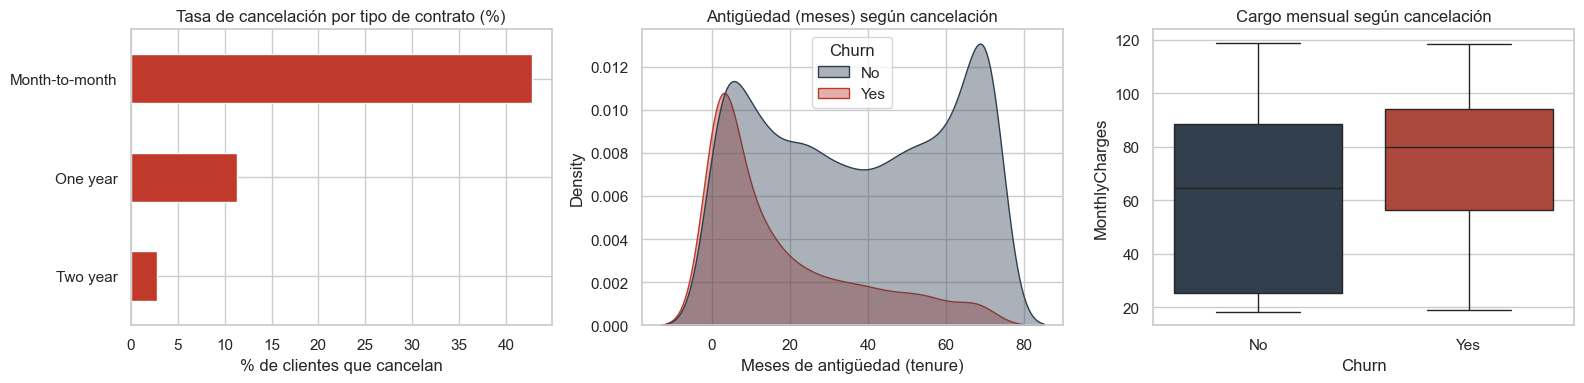

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Churn por tipo de contrato
churn_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
churn_contract['Yes'].sort_values().plot(kind='barh', ax=axes[0], color='#c0392b')
axes[0].set_title('Tasa de cancelación por tipo de contrato (%)')
axes[0].set_xlabel('% de clientes que cancelan')
axes[0].set_ylabel('')

# Distribución de antigüedad por churn
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, alpha=0.4, ax=axes[1], palette=['#2c3e50', '#c0392b'])
axes[1].set_title('Antigüedad (meses) según cancelación')
axes[1].set_xlabel('Meses de antigüedad (tenure)')

# Monthly charges por churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', ax=axes[2], palette=['#2c3e50', '#c0392b'], legend=False)
axes[2].set_title('Cargo mensual según cancelación')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

**Lectura de los hallazgos:**
- Los contratos **mes a mes (Month-to-month)** tienen una tasa de cancelación muy
  superior a los contratos de uno o dos años: el compromiso contractual es uno de los
  predictores más fuertes de retención.
- Los clientes que cancelan tienden a tener **menor antigüedad** (tenure bajo):
  el riesgo de cancelación es mayor en los primeros meses de la relación.
- Los clientes que cancelan pagan en promedio **cargos mensuales más altos**, lo que
  sugiere sensibilidad al precio como factor de cancelación.

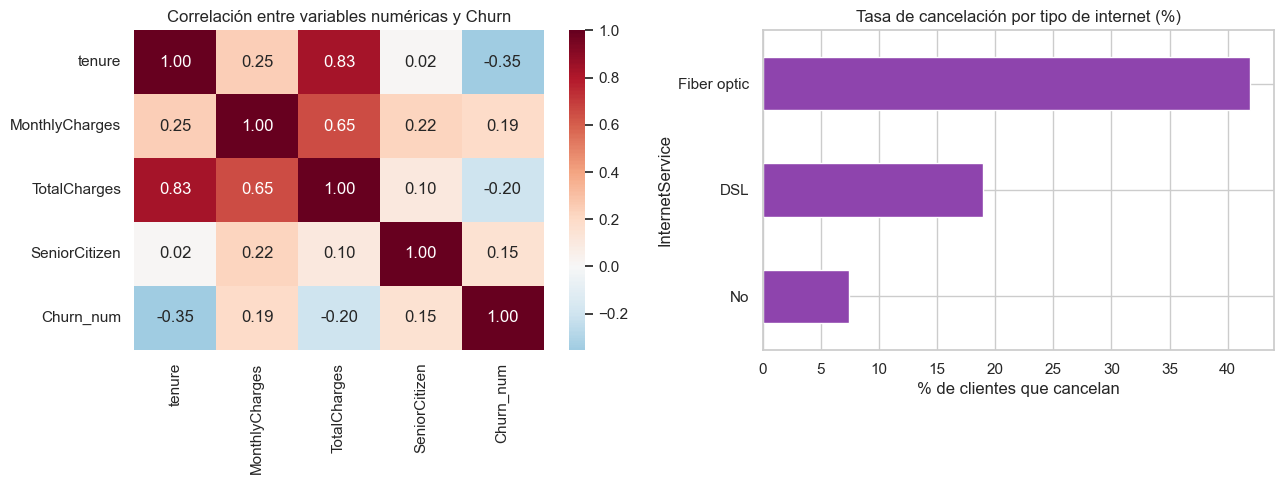

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Correlación de variables numéricas
df_num = df.copy()
df_num['TotalCharges'] = pd.to_numeric(df_num['TotalCharges'], errors='coerce')
df_num['Churn_num'] = (df_num['Churn'] == 'Yes').astype(int)
corr = df_num[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Correlación entre variables numéricas y Churn')

# Churn por servicio de internet
churn_internet = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
churn_internet['Yes'].sort_values().plot(kind='barh', ax=axes[1], color='#8e44ad')
axes[1].set_title('Tasa de cancelación por tipo de internet (%)')
axes[1].set_xlabel('% de clientes que cancelan')

plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=150)
plt.show()

**Lectura:** `tenure` correlaciona negativamente con `Churn` (a mayor antigüedad,
menor cancelación) mientras que `MonthlyCharges` correlaciona positivamente. Los
clientes con **fibra óptica (Fiber optic)** cancelan casi el doble que los de DSL,
posiblemente por mayor costo o mayor competencia en ese segmento — un hallazgo
accionable para el área comercial.

---
## 4. Preprocesamiento de datos

In [6]:
df_clean = df.copy()

# 1) Corregir TotalCharges: texto -> numérico. Los 11 blancos son tenure=0 (clientes nuevos)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print("Registros con TotalCharges nulo tras conversión:", df_clean['TotalCharges'].isna().sum())
print("Todos corresponden a tenure=0:", (df_clean.loc[df_clean['TotalCharges'].isna(), 'tenure'] == 0).all())

# Se imputan con 0, consistente con "sin facturación acumulada todavía" (no es un error, es la realidad del negocio)
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# 2) Eliminar identificador sin valor predictivo
df_clean = df_clean.drop(columns=['customerID'])

# 3) Variable objetivo a binaria
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# 4) Separar variables numéricas y categóricas
target = 'Churn'
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
cat_cols = [c for c in df_clean.columns if c not in num_cols + [target]]
print("\nNuméricas:", num_cols)
print("Categóricas:", cat_cols)

Registros con TotalCharges nulo tras conversión: 11
Todos corresponden a tenure=0: True

Numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Justificación de las decisiones de limpieza:**
- No se eliminaron *outliers* de `MonthlyCharges`/`TotalCharges`: son valores de
  facturación reales y válidos dentro del rango del negocio, no errores de captura.
- `customerID` se descarta porque es un identificador único sin poder predictivo
  (mantenerlo induciría sobreajuste).
- La codificación de variables categóricas y el escalado se ajustan **únicamente con el
  conjunto de entrenamiento** y se aplican al de prueba, para evitar fuga de información
  (*data leakage*).

In [7]:
# 5) Separación X / y y partición train/test (80/20) ANTES de ajustar cualquier transformador
X = df_clean.drop(columns=[target])
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Proporción de churn en train:", y_train.mean().round(3), " | test:", y_test.mean().round(3))

Train: (5634, 19)  Test: (1409, 19)
Proporción de churn en train: 0.265  | test: 0.265


In [8]:
# 6) Codificación de variables categóricas (one-hot), ajustada solo con train
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alinear columnas de test con las de train (por si alguna categoría no aparece en test)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# 7) Escalado de variables numéricas: se ajusta (fit) SOLO con train, se aplica (transform) a ambos
scaler = StandardScaler()
X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_enc[num_cols] = scaler.transform(X_test_enc[num_cols])

print("Features finales tras codificación:", X_train_enc.shape[1])
X_train_enc.head()

Features finales tras codificación: 30


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,-0.441773,0.102371,-0.521976,-0.262257,True,False,False,False,True,False,False,False,...,False,False,False,True,False,True,False,False,False,False,True,False
3151,-0.441773,-0.711743,0.337478,-0.503635,True,True,True,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False,False,True
4860,-0.441773,-0.793155,-0.809013,-0.749883,True,True,True,False,True,False,False,False,...,False,True,False,False,False,False,False,True,False,False,False,True
3867,-0.441773,-0.263980,0.284384,-0.172722,False,True,False,True,False,False,False,False,...,False,False,False,True,False,True,False,True,True,True,False,False
3810,-0.441773,-1.281624,-0.676279,-0.989374,True,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,True,False


---
## 5. Selección, entrenamiento y justificación del algoritmo

**Tipo de problema:** aprendizaje **supervisado** de **clasificación binaria**
(la variable objetivo `Churn` es conocida en el histórico).

**Algoritmo elegido: Random Forest Classifier**, comparado contra una **Regresión
Logística** como línea base.

**Justificación:**
- El churn depende de **interacciones no lineales** entre variables (p. ej. contrato ×
  antigüedad × tipo de internet). Random Forest captura esas interacciones sin
  necesidad de especificarlas manualmente, a diferencia de la regresión logística.
- Maneja de forma natural la mezcla de variables numéricas y categóricas codificadas.
- Es robusto a *outliers* y a escalas distintas entre variables.
- Entrega **importancia de variables**, una salida directamente interpretable para un
  público directivo (qué factores más influyen en la cancelación).
- La regresión logística se conserva como comparación por ser un modelo simple e
  interpretable (coeficientes), útil para verificar que el modelo más complejo
  realmente aporta valor.

In [9]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_enc, y_train)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train_enc, y_train)

print("Modelos entrenados: Logistic Regression (línea base) y Random Forest (modelo principal)")

Modelos entrenados: Logistic Regression (línea base) y Random Forest (modelo principal)


---
## 6. Evaluación del modelo e interpretación de métricas

In [10]:
def evaluar(modelo, nombre, X_te, y_te):
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]
    print(f"--- {nombre} ---")
    print(f"Accuracy : {accuracy_score(y_te, y_pred):.3f}")
    print(f"Precision: {precision_score(y_te, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_te, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_te, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_te, y_proba):.3f}")
    print()
    print(classification_report(y_te, y_pred, target_names=['No cancela', 'Cancela']))
    return y_pred, y_proba

pred_lr, proba_lr = evaluar(log_reg, "Regresión Logística (línea base)", X_test_enc, y_test)
print("="*60)
pred_rf, proba_rf = evaluar(rf, "Random Forest (modelo principal)", X_test_enc, y_test)

--- Regresión Logística (línea base) ---
Accuracy : 0.807
Precision: 0.660
Recall   : 0.561
F1-score : 0.607
ROC-AUC  : 0.842

              precision    recall  f1-score   support

  No cancela       0.85      0.90      0.87      1035
     Cancela       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

--- Random Forest (modelo principal) ---
Accuracy : 0.751
Precision: 0.520
Recall   : 0.786
F1-score : 0.626
ROC-AUC  : 0.845

              precision    recall  f1-score   support

  No cancela       0.91      0.74      0.81      1035
     Cancela       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



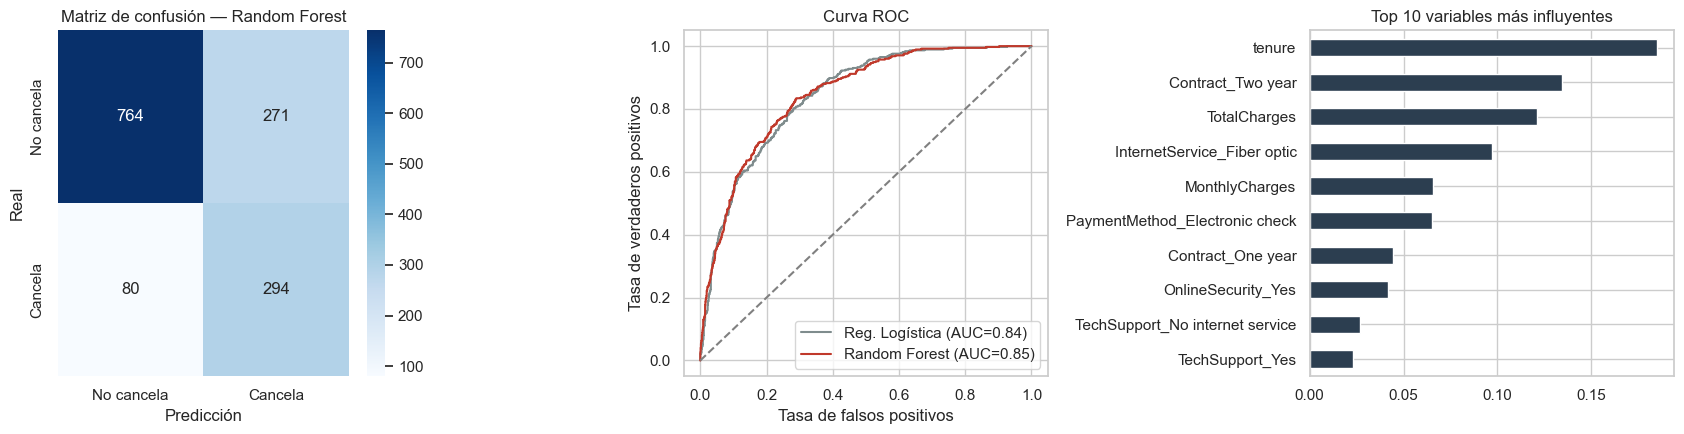

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Matriz de confusión Random Forest
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No cancela', 'Cancela'], yticklabels=['No cancela', 'Cancela'], ax=axes[0])
axes[0].set_title('Matriz de confusión — Random Forest')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Curva ROC comparativa
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
axes[1].plot(fpr_lr, tpr_lr, label=f'Reg. Logística (AUC={roc_auc_score(y_test, proba_lr):.2f})', color='#7f8c8d')
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, proba_rf):.2f})', color='#c0392b')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('Tasa de falsos positivos')
axes[1].set_ylabel('Tasa de verdaderos positivos')
axes[1].set_title('Curva ROC')
axes[1].legend()

# Importancia de variables (top 10)
importances = pd.Series(rf.feature_importances_, index=X_train_enc.columns).sort_values(ascending=False).head(10)
importances.sort_values().plot(kind='barh', ax=axes[2], color='#2c3e50')
axes[2].set_title('Top 10 variables más influyentes')

plt.tight_layout()
plt.savefig('evaluacion_modelo.png', dpi=150)
plt.show()

**Interpretación de resultados y limitaciones:**
- El **Random Forest** supera a la regresión logística en ROC-AUC, confirmando que
  existen relaciones no lineales que el modelo lineal no captura del todo.
- Se usó `class_weight='balanced'` para que el modelo no ignore la clase minoritaria
  (clientes que cancelan, ~26% de los datos); esto **prioriza el recall de "Cancela"**
  sobre la clase mayoritaria, que es la métrica relevante para el negocio: es más
  costoso no detectar a un cliente que se va, que ofrecer una promoción de retención a
  alguien que de todas formas se hubiera quedado.
- **Limitación:** aún existen falsos negativos (clientes que cancelan y el modelo no
  detecta) — ninguna campaña de retención basada en este modelo debe ser el único
  mecanismo de control de cancelación; conviene combinarla con monitoreo manual de
  cuentas de alto valor.
- Las variables más influyentes coinciden con los hallazgos del EDA: tipo de contrato,
  antigüedad (`tenure`), cargos y tipo de servicio de internet, lo que **da consistencia
  interna al análisis**.

---
## 7. Predicción con datos nuevos

In [12]:
# Tres clientes nuevos hipotéticos (no vistos por el modelo), con el MISMO esquema que el dataset original
clientes_nuevos = pd.DataFrame([
    {  # Cliente A: alto riesgo típico (mes a mes, poca antigüedad, fibra óptica cara)
        'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No',
        'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No', 'InternetService': 'Fiber optic',
        'OnlineSecurity': 'No', 'OnlineBackup': 'No', 'DeviceProtection': 'No', 'TechSupport': 'No',
        'StreamingTV': 'Yes', 'StreamingMovies': 'Yes', 'Contract': 'Month-to-month',
        'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 95.5, 'TotalCharges': 191.0
    },
    {  # Cliente B: bajo riesgo típico (contrato largo, antigua, DSL)
        'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes',
        'tenure': 60, 'PhoneService': 'Yes', 'MultipleLines': 'Yes', 'InternetService': 'DSL',
        'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes', 'DeviceProtection': 'Yes', 'TechSupport': 'Yes',
        'StreamingTV': 'No', 'StreamingMovies': 'No', 'Contract': 'Two year',
        'PaperlessBilling': 'No', 'PaymentMethod': 'Bank transfer (automatic)',
        'MonthlyCharges': 55.2, 'TotalCharges': 3312.0
    },
    {  # Cliente C: riesgo intermedio
        'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'No', 'Dependents': 'No',
        'tenure': 14, 'PhoneService': 'Yes', 'MultipleLines': 'No', 'InternetService': 'DSL',
        'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'No',
        'StreamingTV': 'No', 'StreamingMovies': 'No', 'Contract': 'One year',
        'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check',
        'MonthlyCharges': 60.0, 'TotalCharges': 840.0
    },
])

# Se aplica EXACTAMENTE el mismo pipeline de preprocesamiento ajustado con el train
nuevos_enc = pd.get_dummies(clientes_nuevos, columns=cat_cols, drop_first=True)
nuevos_enc = nuevos_enc.reindex(columns=X_train_enc.columns, fill_value=0)
nuevos_enc[num_cols] = scaler.transform(nuevos_enc[num_cols])

pred_nuevos = rf.predict(nuevos_enc)
proba_nuevos = rf.predict_proba(nuevos_enc)[:, 1]

resultado = clientes_nuevos[['tenure', 'Contract', 'InternetService', 'MonthlyCharges']].copy()
resultado['Probabilidad_Cancelacion'] = (proba_nuevos * 100).round(1)
resultado['Prediccion'] = np.where(pred_nuevos == 1, 'CANCELA', 'NO CANCELA')
resultado.insert(0, 'Cliente', ['A', 'B', 'C'])
resultado

,Cliente,tenure,Contract,InternetService,MonthlyCharges,Probabilidad_Cancelacion,Prediccion
0,A,2,Month-to-month,Fiber optic,95.5,87.4,CANCELA
1,B,60,Two year,DSL,55.2,5.2,NO CANCELA
2,C,14,One year,DSL,60.0,39.7,NO CANCELA


**Interpretación para el negocio:**
- **Cliente A** (contrato mes a mes, apenas 2 meses de antigüedad, fibra óptica cara):
  el modelo le asigna **alta probabilidad de cancelación** → candidato prioritario para
  una llamada de retención o una oferta de descuento en los primeros meses.
- **Cliente B** (contrato de dos años, 5 años de antigüedad, servicios adicionales
  contratados): **bajo riesgo** → no requiere acción inmediata, es un cliente estable.
- **Cliente C** (contrato de un año, antigüedad media): **riesgo intermedio** → se
  recomienda monitoreo, no necesariamente una acción comercial inmediata.

Esto demuestra que el pipeline completo (limpieza → codificación → escalado → modelo)
es **reproducible sobre datos nunca vistos**, tal como se aplicaría en producción sobre
la base de clientes activos cada mes.

---
## 8. Conclusiones y recomendaciones

1. **El tipo de contrato es el factor más determinante de la cancelación.** Migrar
   clientes de "mes a mes" a contratos de uno o dos años (con incentivo) es la palanca
   de retención de mayor impacto potencial.
2. **Los primeros meses de vida del cliente son el periodo de mayor riesgo.** Se
   recomienda un programa de acompañamiento/onboarding reforzado durante los primeros
   3-6 meses.
3. **El servicio de fibra óptica concentra más cancelaciones que el DSL**, pese a ser el
   servicio premium; conviene revisar percepción de precio/valor en ese segmento.
4. **Riesgos y limitaciones:** el modelo prioriza detectar a quienes cancelan (mayor
   recall) a costa de algunas falsas alarmas (clientes marcados como riesgo que en
   realidad se quedarían); el costo de una promoción no solicitada es mucho menor que
   el de perder al cliente, por lo que este balance es deseable para el negocio, pero
   debe monitorearse el costo de las campañas de retención.
5. **Recomendación operativa:** integrar el `Probabilidad_Cancelacion` como un campo
   mensual en el CRM comercial, priorizando contacto proactivo hacia el decil superior
   de riesgo, especialmente en clientes con `MonthlyCharges` altos (mayor valor en
   riesgo).
